### Importing Importing Libraries

In [10]:
# Importing Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, LSTM
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Importing the data in DataFrame
df = pd.read_csv("AAPL.csv")

# Display the data
print(df.head())
print(df.info())

         Date      Open      High       Low     Close  Adj Close       Volume
0  1980-12-12  0.513393  0.515625  0.513393  0.513393   0.407747  117258400.0
1  1980-12-15  0.488839  0.488839  0.486607  0.486607   0.386473   43971200.0
2  1980-12-16  0.453125  0.453125  0.450893  0.450893   0.358108   26432000.0
3  1980-12-17  0.462054  0.464286  0.462054  0.462054   0.366972   21610400.0
4  1980-12-18  0.475446  0.477679  0.475446  0.475446   0.377609   18362400.0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9823 entries, 0 to 9822
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       9823 non-null   object 
 1   Open       9822 non-null   float64
 2   High       9822 non-null   float64
 3   Low        9822 non-null   float64
 4   Close      9822 non-null   float64
 5   Adj Close  9822 non-null   float64
 6   Volume     9822 non-null   float64
dtypes: float64(6), object(1)
memory usage: 537.3+ KB
None


In [4]:
# Converting data column to datetime and set index
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace = False)

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
1980-12-12,0.513393,0.515625,0.513393,0.513393,0.407747,117258400.0
1980-12-15,0.488839,0.488839,0.486607,0.486607,0.386473,43971200.0
1980-12-16,0.453125,0.453125,0.450893,0.450893,0.358108,26432000.0
1980-12-17,0.462054,0.464286,0.462054,0.462054,0.366972,21610400.0
1980-12-18,0.475446,0.477679,0.475446,0.475446,0.377609,18362400.0
...,...,...,...,...,...,...
2019-11-19,267.899994,268.000000,265.390015,266.290009,266.290009,19041800.0
2019-11-20,265.540009,266.079987,260.399994,263.190002,263.190002,26558600.0
2019-11-21,263.690002,264.010010,261.179993,262.010010,262.010010,30348800.0


In [5]:
df.isnull().sum()

Date         0
Open         1
High         1
Low          1
Close        1
Adj Close    1
Volume       1
dtype: int64

In [6]:
# Cleaning the Null Values 
df = df.dropna().reset_index(drop=True)

In [7]:
df.isnull().sum()

Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

In [8]:
# Use Close price for prediction
data = df["Close"].values.reshape(-1, 1)

### Scaling 

In [11]:
scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(data)

### Prepare sequences

In [12]:
def create_sequences(dataset, seq_length=60):
    X, y = [], []
    for i in range(len(dataset) - seq_length):
        X.append(dataset[i:i+seq_length])
        y.append(dataset[i+seq_length])
    return np.array(X), np.array(y)

seq_length = 60
X, y = create_sequences(data_scaled, seq_length)

In [13]:
# Train-test split
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

### Define models

In [14]:
def build_simplernn(input_shape):
    model = Sequential([
        SimpleRNN(50, activation='tanh', return_sequences=False, input_shape=input_shape),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

def build_lstm(input_shape):
    model = Sequential([
        LSTM(50, activation='tanh', return_sequences=False, input_shape=input_shape),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

### Train models

In [15]:
simplernn = build_simplernn((X_train.shape[1], X_train.shape[2]))
lstm = build_lstm((X_train.shape[1], X_train.shape[2]))

simplernn.fit(X_train, y_train, epochs=5, batch_size=32, verbose=1)
lstm.fit(X_train, y_train, epochs=5, batch_size=32, verbose=1)

Epoch 1/5
245/245 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 3.1450e-04
Epoch 2/5
245/245 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 9.9992e-06
Epoch 3/5
245/245 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.0677e-06
Epoch 4/5
245/245 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 4.8695e-06
Epoch 5/5
245/245 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 4.7034e-06
Epoch 1/5
245/245 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 1.1659e-04
Epoch 2/5
245/245 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 5.2722e-06
Epoch 3/5
245/245 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 5.2811e-06
Epoch 4/5
245/245 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 4.8871e-06
Epoch 5/5
245/245 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 4.8926e-06


### Predictions

In [16]:
y_pred_simplernn_scaled = simplernn.predict(X_test)
y_pred_lstm_scaled = lstm.predict(X_test)

62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step


In [17]:
# Replace NaNs if any
y_pred_simplernn_scaled = np.nan_to_num(y_pred_simplernn_scaled)
y_pred_lstm_scaled = np.nan_to_num(y_pred_lstm_scaled)

In [18]:
# Inverse scaling
y_test_inv = scaler.inverse_transform(y_test.reshape(-1, 1)).ravel()
y_pred_simplernn = scaler.inverse_transform(y_pred_simplernn_scaled).ravel()
y_pred_lstm = scaler.inverse_transform(y_pred_lstm_scaled).ravel()

### Evaluation

In [19]:
mse_simplernn = mean_squared_error(y_test_inv, y_pred_simplernn)
mse_lstm = mean_squared_error(y_test_inv, y_pred_lstm)

print(f"MSE - SimpleRNN: {mse_simplernn:.4f}")
print(f"MSE - LSTM: {mse_lstm:.4f}")

MSE - SimpleRNN: 164.1693
MSE - LSTM: 14.0942


### Visualization

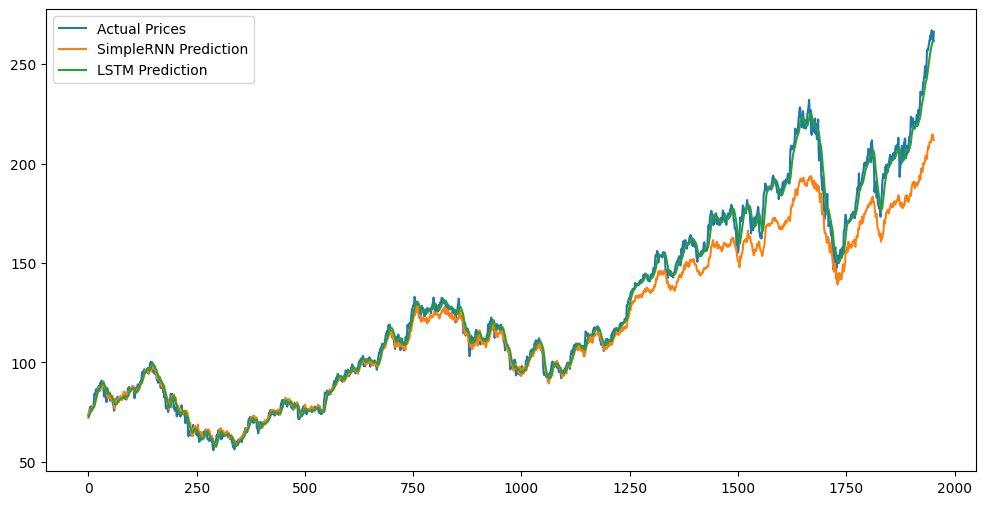

In [20]:
plt.figure(figsize=(12,6))
plt.plot(y_test_inv, label="Actual Prices")
plt.plot(y_pred_simplernn, label="SimpleRNN Prediction")
plt.plot(y_pred_lstm, label="LSTM Prediction")
plt.legend()
plt.show()

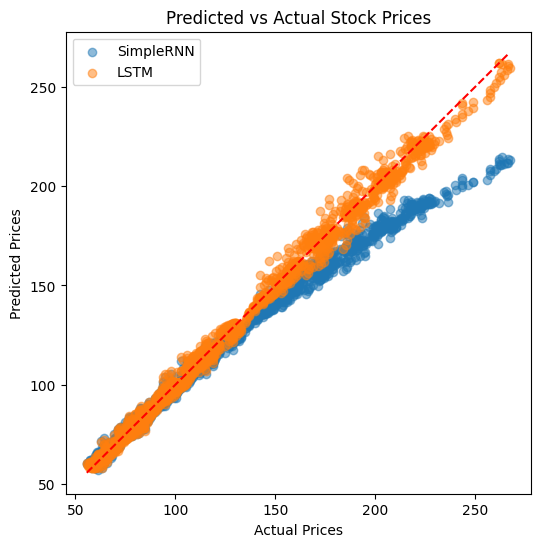

In [21]:
# Scatter Plot
plt.figure(figsize=(6,6))
plt.scatter(y_test_inv, y_pred_simplernn, alpha=0.5, label="SimpleRNN")
plt.scatter(y_test_inv, y_pred_lstm, alpha=0.5, label="LSTM")
plt.plot([min(y_test_inv), max(y_test_inv)], [min(y_test_inv), max(y_test_inv)], 'r--')
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Predicted vs Actual Stock Prices")
plt.legend()
plt.show()